In [1]:
import pandas as pd

df = pd.read_csv('../data/processed/preprocessed_daily.csv',
                  parse_dates=['date'], dtype={'station_id': str}, low_memory=False)

summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'non_null_count': df.notna().sum(),
    'missing_pct': (df.isna().mean()*100).round(1),
    'example_value': df.iloc[0],
})
summary

,dtype,non_null_count,missing_pct,example_value
date,datetime64[us],4872,0.0,2024-01-01 00:00:00
station_id,str,4872,0.0,MUB001
station_name,str,4872,0.0,MUB001 - Melbourne Street
station_lat,float64,4872,0.0,-36.003071
station_lon,float64,4872,0.0,146.003235
station_suburb,str,4872,0.0,Mulwala
station_lga,str,4872,0.0,Corowa
traffic_volume_total,float64,4872,0.0,11876.0
traffic_volume_light,float64,4872,0.0,11074.0
traffic_volume_heavy,float64,4872,0.0,802.0


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/preprocessed_daily.csv',
                  parse_dates=['date'], dtype={'station_id': str}, low_memory=False)

def classify_road(name):
    n = name.lower()
    if 'highway' in n or 'motorway' in n or 'freeway' in n:
        return 'Highway'
    elif 'road' in n or 'way' in n or 'drive' in n or 'parade' in n:
        return 'Major Road'
    else:
        return 'Local Street'

places = df.drop_duplicates('station_id')[
    ['station_id','station_name','station_suburb','station_lga','station_lat','station_lon']
].copy()
places['road_type'] = places['station_name'].apply(classify_road)
places = places.sort_values('road_type').reset_index(drop=True)

# --- Table ---
places[['station_id','station_name','station_suburb','station_lga','road_type']]

,station_id,station_name,station_suburb,station_lga,road_type
0,6135-PR,6135-PR - M31 Hume Highway,Bowning,Yass Valley,Highway
1,6119-PR,6119-PR - Pacific Highway,Nabiac,Greater Taree,Highway
2,6109,6109 - M23 Federal Highway,Yarra,Goulburn Mulwaree,Highway
3,MUB001,MUB001 - Melbourne Street,Mulwala,Corowa,Local Street
4,7212,7212 - Stewart Avenue,Newcastle West,Newcastle,Local Street
5,7211,7211 - Lily Lane,Adamstown,Newcastle,Local Street
6,7216,7216 - Gladstone Avenue,Wollongong,Wollongong,Local Street
7,100001,100001 - Cambridge Street,Canley Heights,Fairfield,Local Street
8,6124,6124 - Macleay Valley Way,South Kempsey,Kempsey,Major Road
9,10011,10011 - New South Head Road,Edgecliff,Woollahra,Major Road


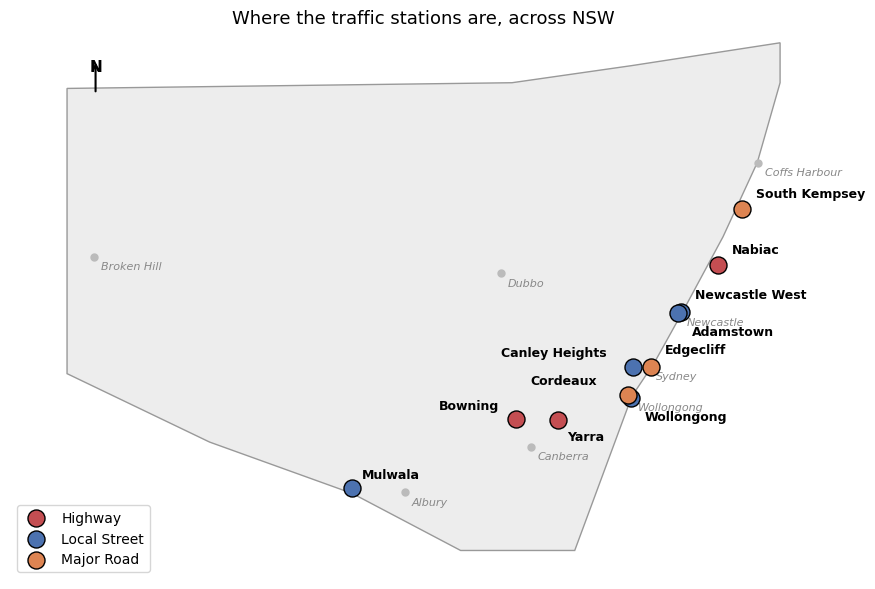

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

df = pd.read_csv('../data/processed/preprocessed_daily.csv',
                  parse_dates=['date'], dtype={'station_id': str}, low_memory=False)

def classify_road(name):
    n = name.lower()
    if 'highway' in n or 'motorway' in n or 'freeway' in n:
        return 'Highway'
    elif 'road' in n or 'way' in n or 'drive' in n or 'parade' in n:
        return 'Major Road'
    else:
        return 'Local Street'

places = df.drop_duplicates('station_id')[
    ['station_id','station_name','station_suburb','station_lga','station_lat','station_lon']
].copy()
places['road_type'] = places['station_name'].apply(classify_road)

nsw_outline = [
    (141.0, -29.0), (141.0, -34.0), (143.5, -35.2), (146.0, -36.1),
    (147.9, -37.1), (149.9, -37.1), (150.9, -34.4), (151.3, -33.8),
    (151.8, -32.9), (152.5, -31.6), (153.1, -30.3), (153.5, -28.9),
    (153.5, -28.2), (150.9, -28.6), (148.8, -28.9), (141.0, -29.0),
]

reference_cities = {
    'Sydney': (151.21, -33.87), 'Newcastle': (151.75, -32.93), 'Wollongong': (150.89, -34.42),
    'Canberra': (149.13, -35.28), 'Dubbo': (148.61, -32.24), 'Albury': (146.92, -36.08),
    'Coffs Harbour': (153.11, -30.30), 'Broken Hill': (141.47, -31.95),
}

colors = {'Highway': '#C44E52', 'Major Road': '#DD8452', 'Local Street': '#4C72B0'}
fig, ax = plt.subplots(figsize=(9,9))
ax.add_patch(Polygon(nsw_outline, closed=True, facecolor='#EDEDED', edgecolor='#999999', zorder=1))

for city, (lon, lat) in reference_cities.items():
    ax.scatter(lon, lat, color='#BBBBBB', s=25, zorder=2)
    ax.annotate(city, (lon, lat), fontsize=8, color='#888888',
                xytext=(5, -9), textcoords='offset points', style='italic', zorder=2)

for road_type, group in places.groupby('road_type'):
    ax.scatter(group['station_lon'], group['station_lat'], label=road_type,
               color=colors[road_type], s=150, edgecolor='black', zorder=4)

label_offsets = {
    'Mulwala': (7, 7), 'Bowning': (-55, 7), 'Yarra': (7, -14),
    'Newcastle West': (10, 10), 'Adamstown': (10, -16),
    'Canley Heights': (-95, 8), 'Edgecliff': (10, 10),
    'Wollongong': (10, -16), 'Cordeaux': (-70, 8),
    'South Kempsey': (10, 8), 'Nabiac': (10, 8),
}
for _, row in places.iterrows():
    dx, dy = label_offsets.get(row['station_suburb'], (7, 7))
    ax.annotate(row['station_suburb'], (row['station_lon'], row['station_lat']),
                fontsize=9, fontweight='bold', xytext=(dx, dy), textcoords='offset points', zorder=5)

ax.set_xlim(140, 154.5); ax.set_ylim(-37.6, -28)
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title('Where the traffic stations are, across NSW', fontsize=13)
ax.set_aspect('equal')
ax.annotate('N', xy=(141.5, -28.7), fontsize=11, fontweight='bold', ha='center')
ax.annotate('', xy=(141.5, -28.5), xytext=(141.5, -29.1), arrowprops=dict(arrowstyle='->', lw=1.5))
ax.legend(loc='lower left', frameon=True)
plt.tight_layout()
plt.show()

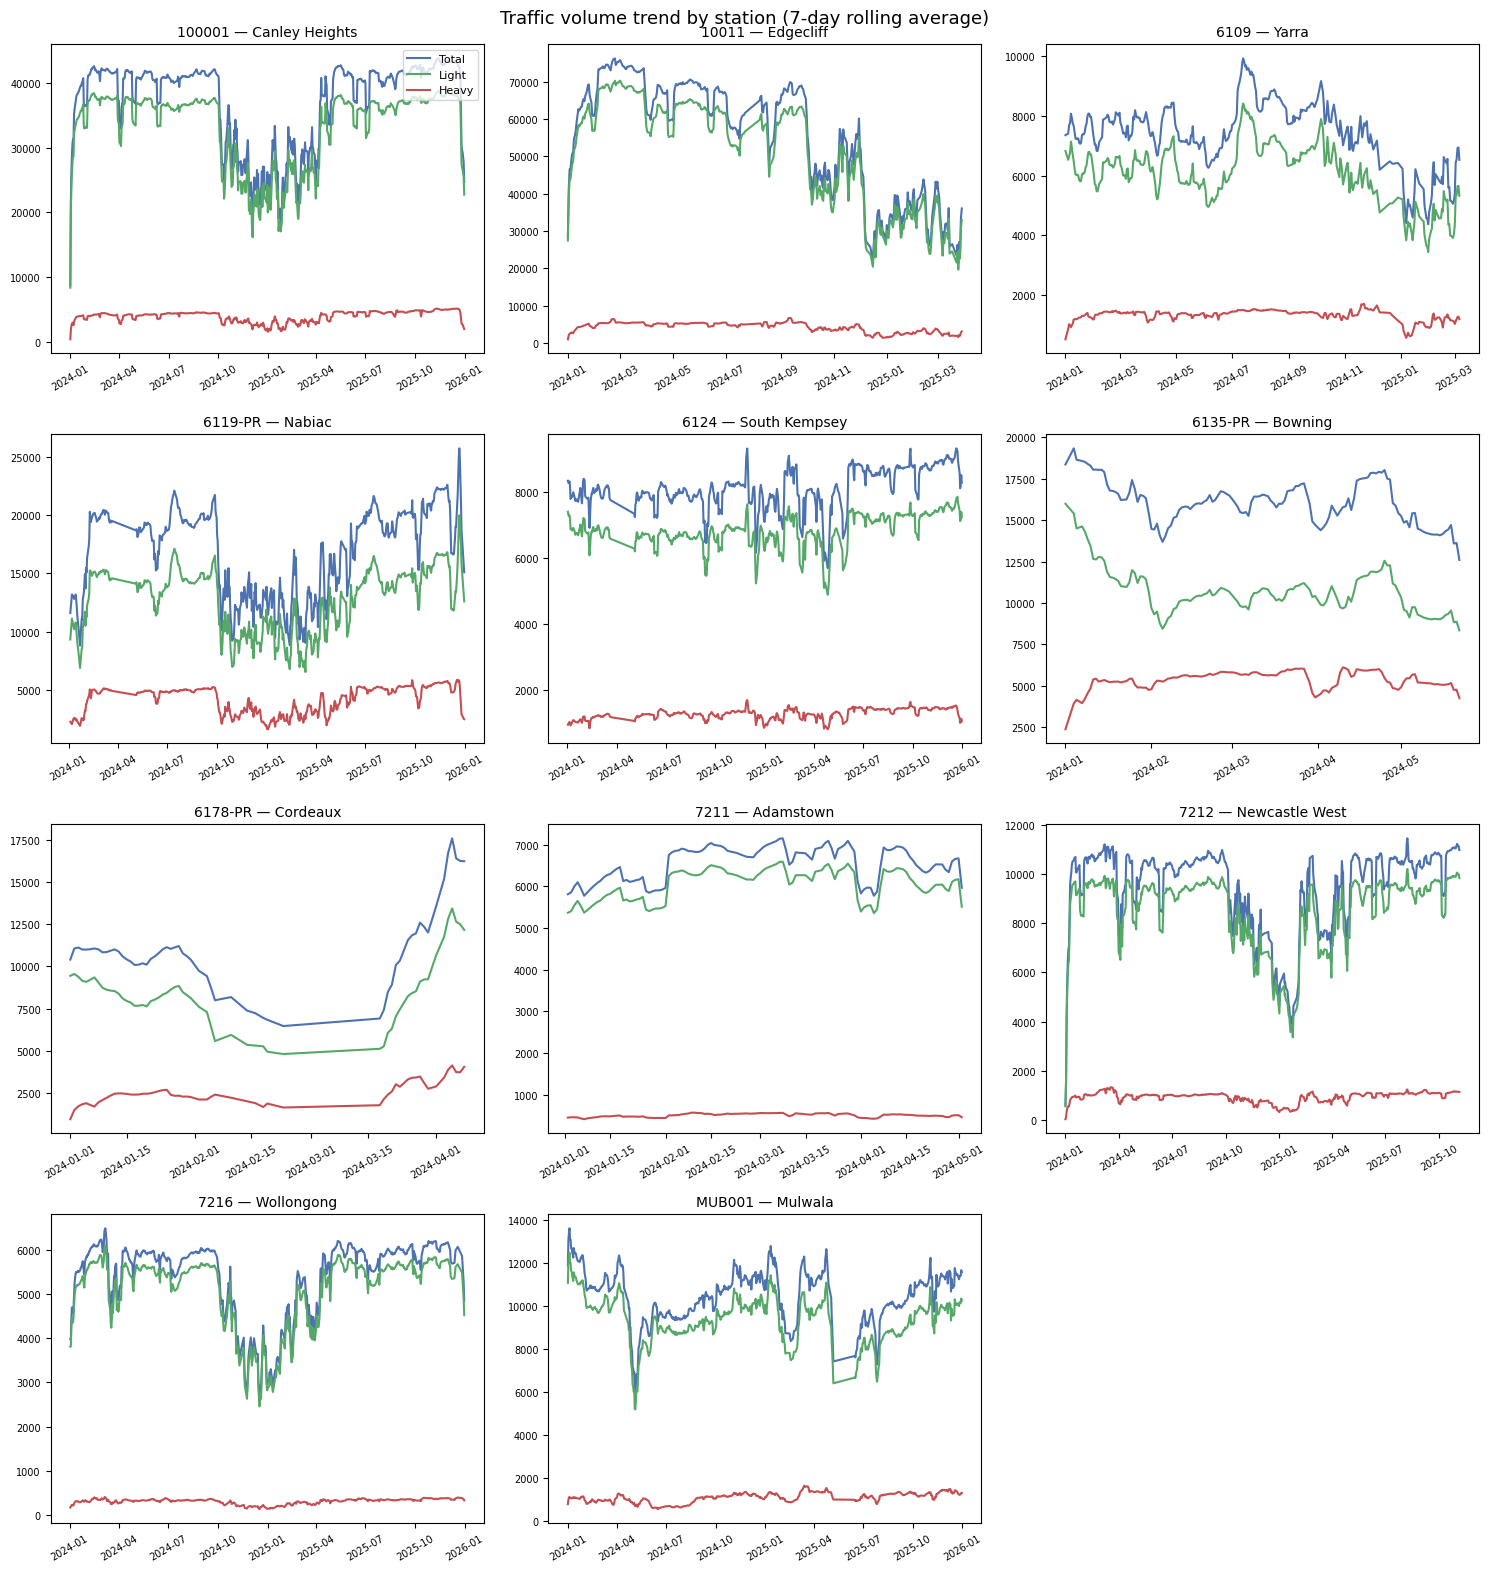

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/preprocessed_daily.csv',
                  parse_dates=['date'], dtype={'station_id': str}, low_memory=False)

stations = sorted(df['station_id'].unique())
n = len(stations)
ncols = 3
nrows = -(-n // ncols)  # ceil division

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4*nrows))
axes = axes.flatten()

for i, sid in enumerate(stations):
    ax = axes[i]
    g = df[df['station_id'] == sid].sort_values('date')
    ax.plot(g['date'], g['traffic_volume_total'].rolling(7, min_periods=1).mean(), label='Total', color='#4C72B0')
    ax.plot(g['date'], g['traffic_volume_light'].rolling(7, min_periods=1).mean(), label='Light', color='#55A868')
    ax.plot(g['date'], g['traffic_volume_heavy'].rolling(7, min_periods=1).mean(), label='Heavy', color='#C44E52')
    ax.set_title(f"{sid} — {g['station_suburb'].iloc[0]}", fontsize=10)
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

axes[0].legend(fontsize=8, loc='upper right')
fig.suptitle('Traffic volume trend by station (7-day rolling average)', fontsize=13)
plt.tight_layout()
plt.show()

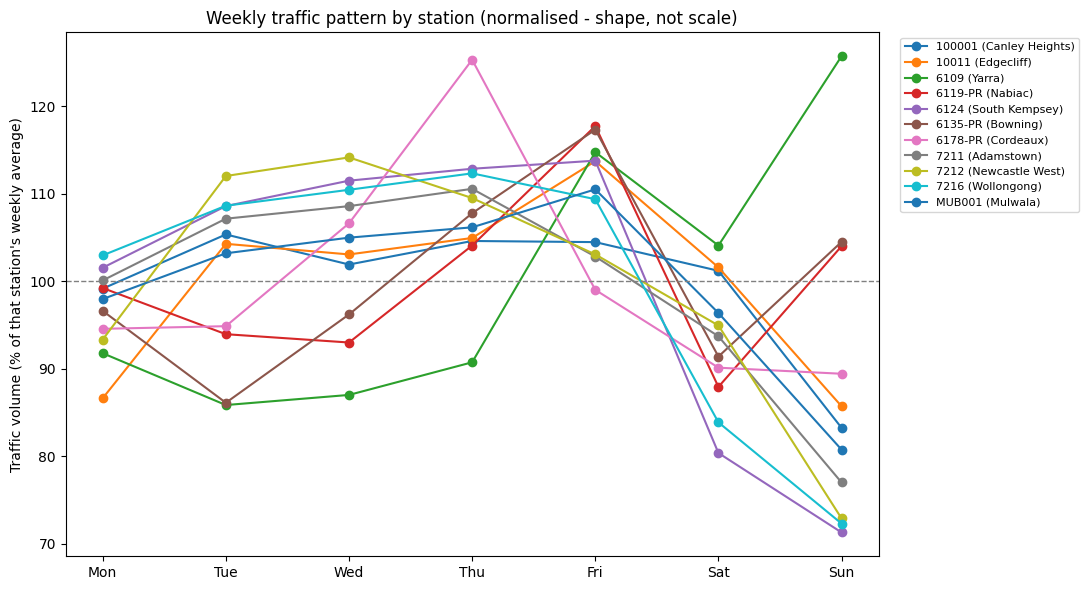

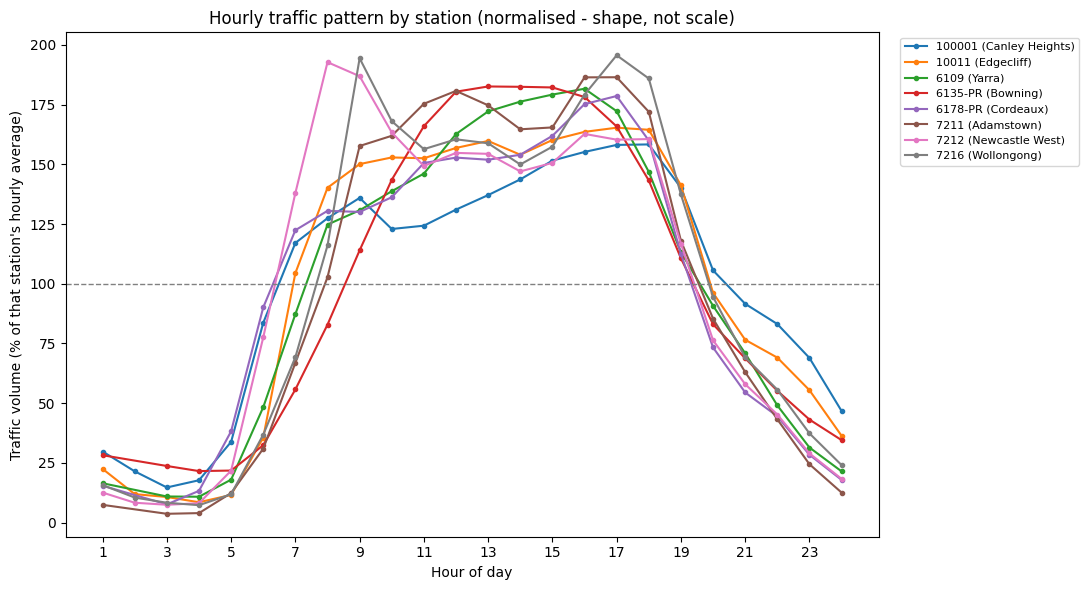

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

daily = pd.read_csv('../data/processed/preprocessed_daily.csv',
                     parse_dates=['date'], dtype={'station_id': str}, low_memory=False)
hourly = pd.read_csv('../data/processed/preprocessed_hourly.csv',
                      parse_dates=['date'], dtype={'station_id': str}, low_memory=False)

# --- Weekly pattern ---
daily['dow'] = daily['date'].dt.dayofweek
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, ax = plt.subplots(figsize=(11,6))
for sid, g in daily.groupby('station_id'):
    weekly = g.groupby('dow')['traffic_volume_total'].mean()
    weekly_norm = weekly / weekly.mean() * 100   # normalise so all stations sit on one axis
    suburb = g['station_suburb'].iloc[0]
    ax.plot(dow_labels, weekly_norm.values, marker='o', label=f"{sid} ({suburb})")
ax.axhline(100, color='gray', linestyle='--', linewidth=1)
ax.set_ylabel("Traffic volume (% of that station's weekly average)")
ax.set_title('Weekly traffic pattern by station (normalised - shape, not scale)')
ax.legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

# --- Hourly pattern ---
fig, ax = plt.subplots(figsize=(11,6))
for sid, g in hourly.groupby('station_id'):
    hourly_profile = g.groupby('hour_ending')['traffic_volume_total'].mean()
    hourly_norm = hourly_profile / hourly_profile.mean() * 100
    suburb = g['station_suburb'].iloc[0]
    ax.plot(hourly_profile.index, hourly_norm.values, marker='o', markersize=3, label=f"{sid} ({suburb})")
ax.axhline(100, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Hour of day'); ax.set_ylabel("Traffic volume (% of that station's hourly average)")
ax.set_title('Hourly traffic pattern by station (normalised - shape, not scale)')
ax.set_xticks(range(1,25,2))
ax.legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

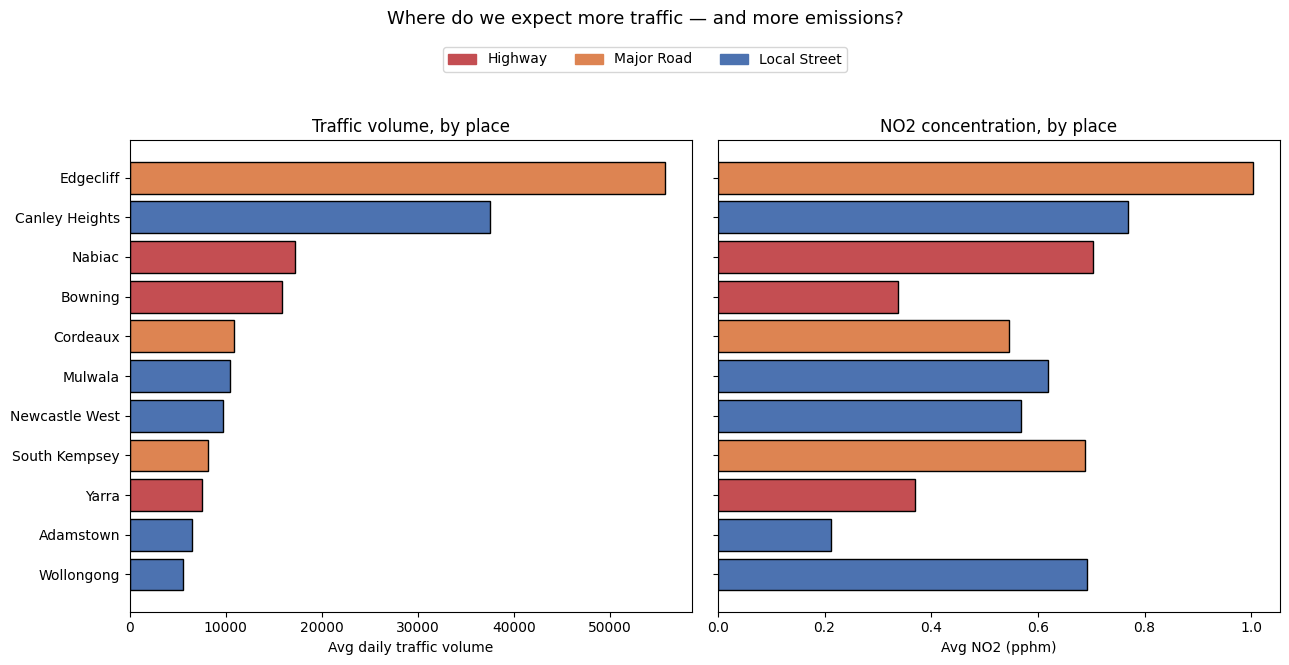

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

df = pd.read_csv('../data/processed/preprocessed_daily.csv',
                  parse_dates=['date'], dtype={'station_id': str}, low_memory=False)

def classify_road(name):
    n = name.lower()
    if 'highway' in n or 'motorway' in n or 'freeway' in n:
        return 'Highway'
    elif 'road' in n or 'way' in n or 'drive' in n or 'parade' in n:
        return 'Major Road'
    else:
        return 'Local Street'

df['road_type'] = df['station_name'].apply(classify_road)

summary = df.groupby(['station_id','station_suburb','road_type']).agg(
    avg_traffic=('traffic_volume_total','mean'),
    avg_no2=('no2_pphm','mean'),
).reset_index().sort_values('avg_traffic', ascending=True)

colors = {'Highway': '#C44E52', 'Major Road': '#DD8452', 'Local Street': '#4C72B0'}
bar_colors = summary['road_type'].map(colors)

fig, axes = plt.subplots(1, 2, figsize=(13,6), sharey=True)
axes[0].barh(summary['station_suburb'], summary['avg_traffic'], color=bar_colors, edgecolor='black')
axes[0].set_xlabel('Avg daily traffic volume'); axes[0].set_title('Traffic volume, by place')
axes[1].barh(summary['station_suburb'], summary['avg_no2'], color=bar_colors, edgecolor='black')
axes[1].set_xlabel('Avg NO2 (pphm)'); axes[1].set_title('NO2 concentration, by place')

handles = [Patch(color=c, label=t) for t, c in colors.items()]
fig.legend(handles=handles, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.05))
fig.suptitle('Where do we expect more traffic — and more emissions?', y=1.1, fontsize=13)
plt.tight_layout()
plt.show()

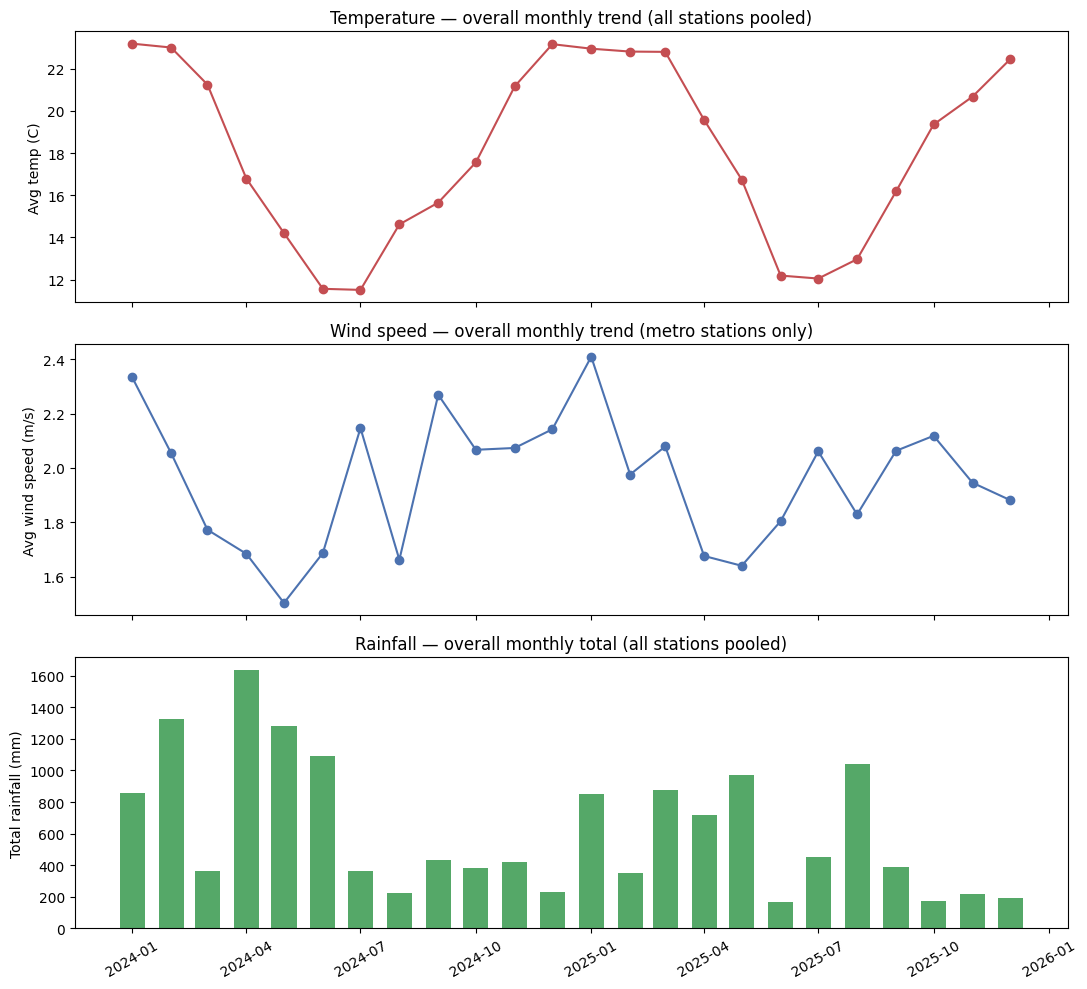

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/preprocessed_daily.csv',
                  parse_dates=['date'], dtype={'station_id': str}, low_memory=False)
df['month'] = df['date'].dt.to_period('M').dt.to_timestamp()

monthly = df.groupby('month').agg(
    avg_temp=('temp_c','mean'),
    avg_wind=('wind_speed_ms','mean'),
    total_rain=('rain_mm','sum'),
).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(11,10), sharex=True)

axes[0].plot(monthly['month'], monthly['avg_temp'], marker='o', color='#C44E52')
axes[0].set_ylabel('Avg temp (C)')
axes[0].set_title('Temperature — overall monthly trend (all stations pooled)')

axes[1].plot(monthly['month'], monthly['avg_wind'], marker='o', color='#4C72B0')
axes[1].set_ylabel('Avg wind speed (m/s)')
axes[1].set_title('Wind speed — overall monthly trend (metro stations only)')

axes[2].bar(monthly['month'], monthly['total_rain'], width=20, color='#55A868')
axes[2].set_ylabel('Total rainfall (mm)')
axes[2].set_title('Rainfall — overall monthly total (all stations pooled)')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

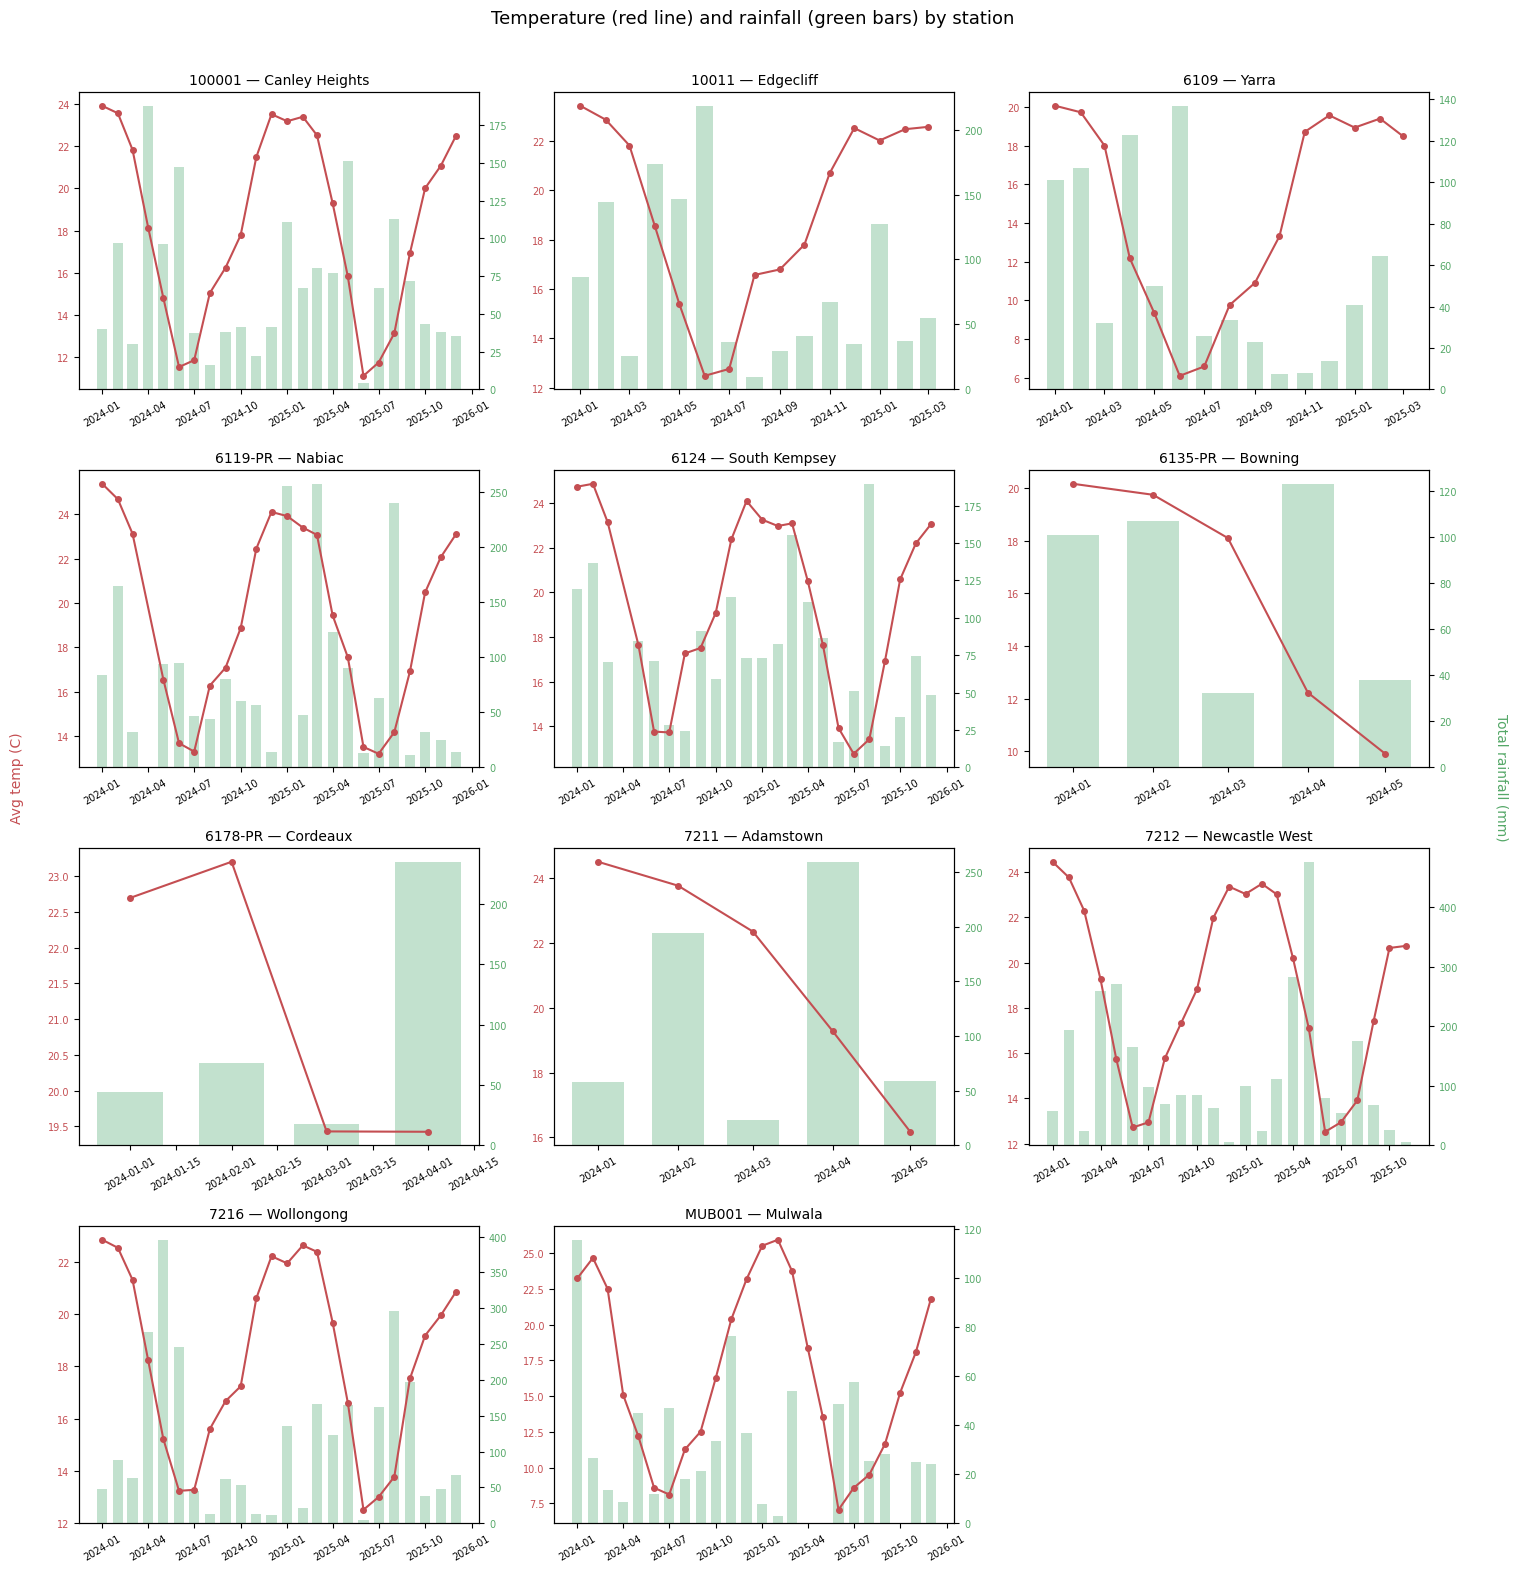

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/preprocessed_daily.csv',
                  parse_dates=['date'], dtype={'station_id': str}, low_memory=False)
df['month'] = df['date'].dt.to_period('M').dt.to_timestamp()

stations = sorted(df['station_id'].unique())
n = len(stations)
ncols = 3
nrows = -(-n // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4*nrows))
axes = axes.flatten()

for i, sid in enumerate(stations):
    g = df[df['station_id'] == sid]
    monthly = g.groupby('month').agg(avg_temp=('temp_c','mean'), total_rain=('rain_mm','sum')).reset_index()
    suburb = g['station_suburb'].iloc[0]

    ax1 = axes[i]
    ax2 = ax1.twinx()
    ax2.bar(monthly['month'], monthly['total_rain'], width=20, color='#A8D5BA', alpha=0.7, zorder=1)
    ax1.plot(monthly['month'], monthly['avg_temp'], marker='o', color='#C44E52', zorder=2, markersize=4)

    ax1.set_title(f"{sid} — {suburb}", fontsize=10)
    ax1.tick_params(axis='x', rotation=30, labelsize=7)
    ax1.tick_params(axis='y', labelsize=7, labelcolor='#C44E52')
    ax2.tick_params(axis='y', labelsize=7, labelcolor='#55A868')
    ax1.set_zorder(2); ax1.patch.set_visible(False)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Temperature (red line) and rainfall (green bars) by station', fontsize=13)
fig.text(0.005, 0.5, 'Avg temp (C)', va='center', rotation='vertical', fontsize=10, color='#C44E52')
fig.text(0.995, 0.5, 'Total rainfall (mm)', va='center', rotation=-90, fontsize=10, color='#55A868')
plt.tight_layout(rect=[0.02, 0, 0.98, 0.97])
plt.show()

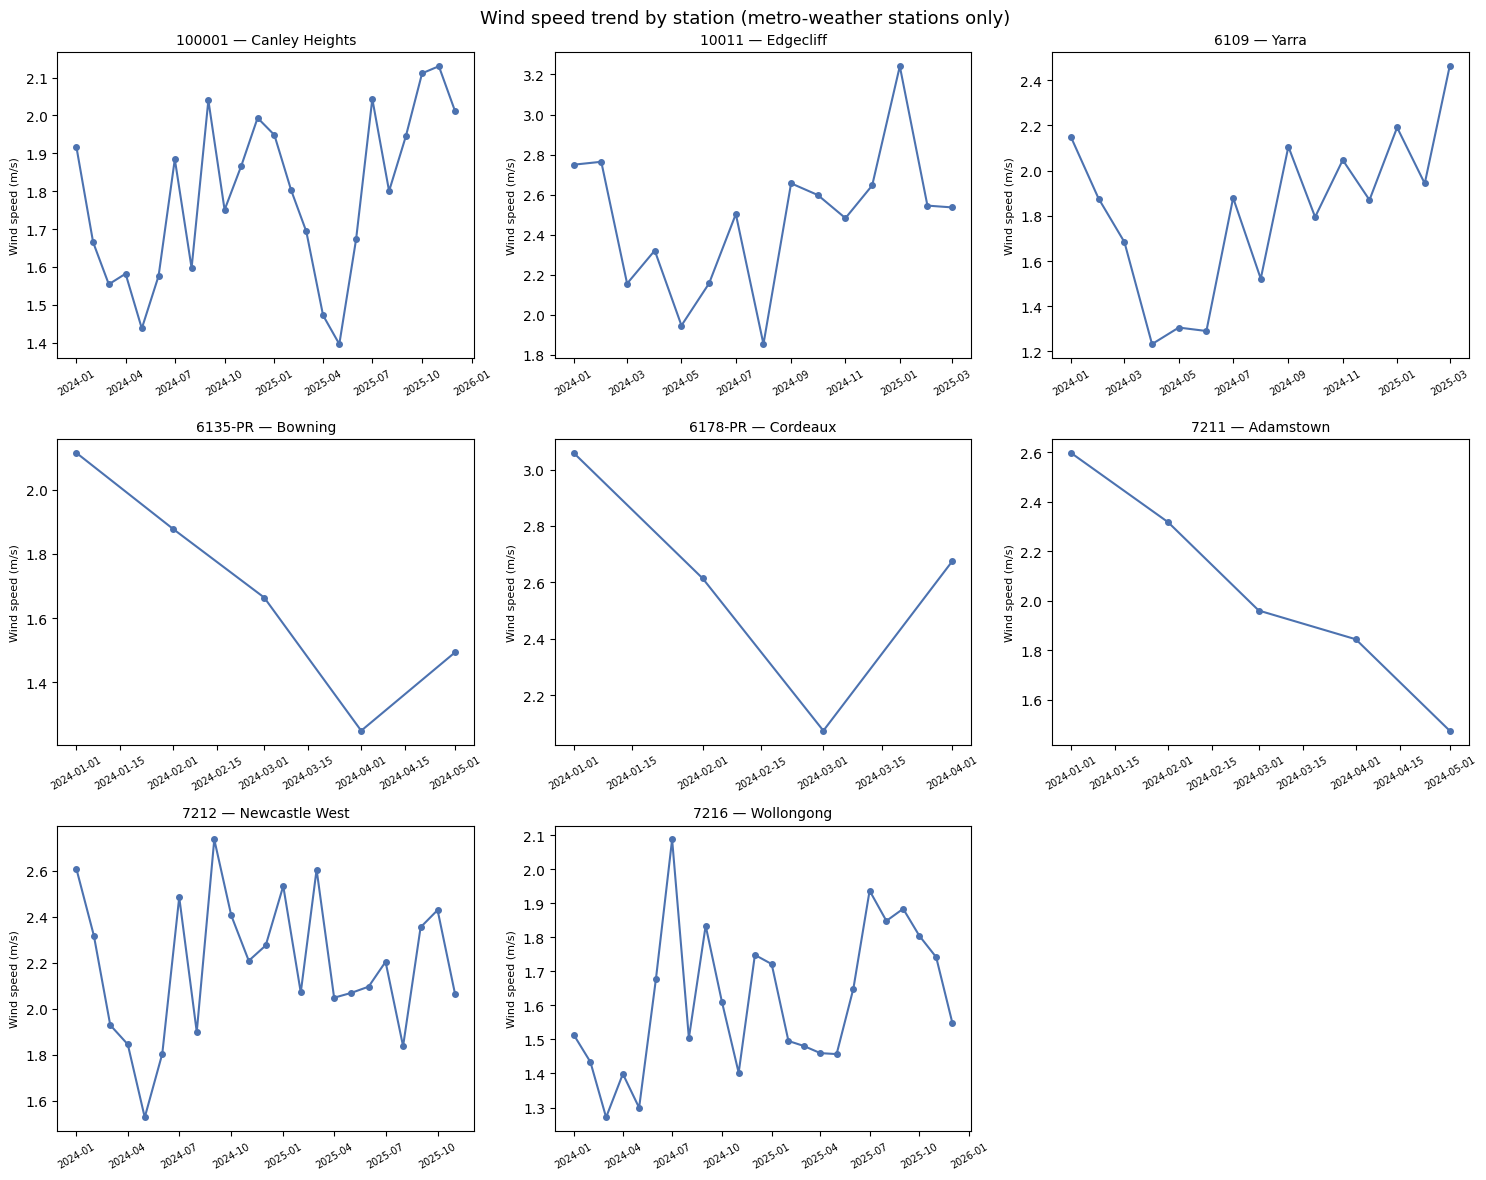

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/processed/preprocessed_daily.csv',
                  parse_dates=['date'], dtype={'station_id': str}, low_memory=False)
df['month'] = df['date'].dt.to_period('M').dt.to_timestamp()

wind_stations = sorted(df.loc[df['wind_speed_ms'].notna(), 'station_id'].unique())

n = len(wind_stations)
ncols = 3
nrows = -(-n // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4*nrows))
axes = axes.flatten()

for i, sid in enumerate(wind_stations):
    g = df[df['station_id'] == sid]
    monthly = g.groupby('month')['wind_speed_ms'].mean().reset_index()
    suburb = g['station_suburb'].iloc[0]

    ax = axes[i]
    ax.plot(monthly['month'], monthly['wind_speed_ms'], marker='o', color='#4C72B0', markersize=4)
    ax.set_title(f"{sid} — {suburb}", fontsize=10)
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.set_ylabel('Wind speed (m/s)', fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Wind speed trend by station (metro-weather stations only)', fontsize=13)
plt.tight_layout()
plt.show()

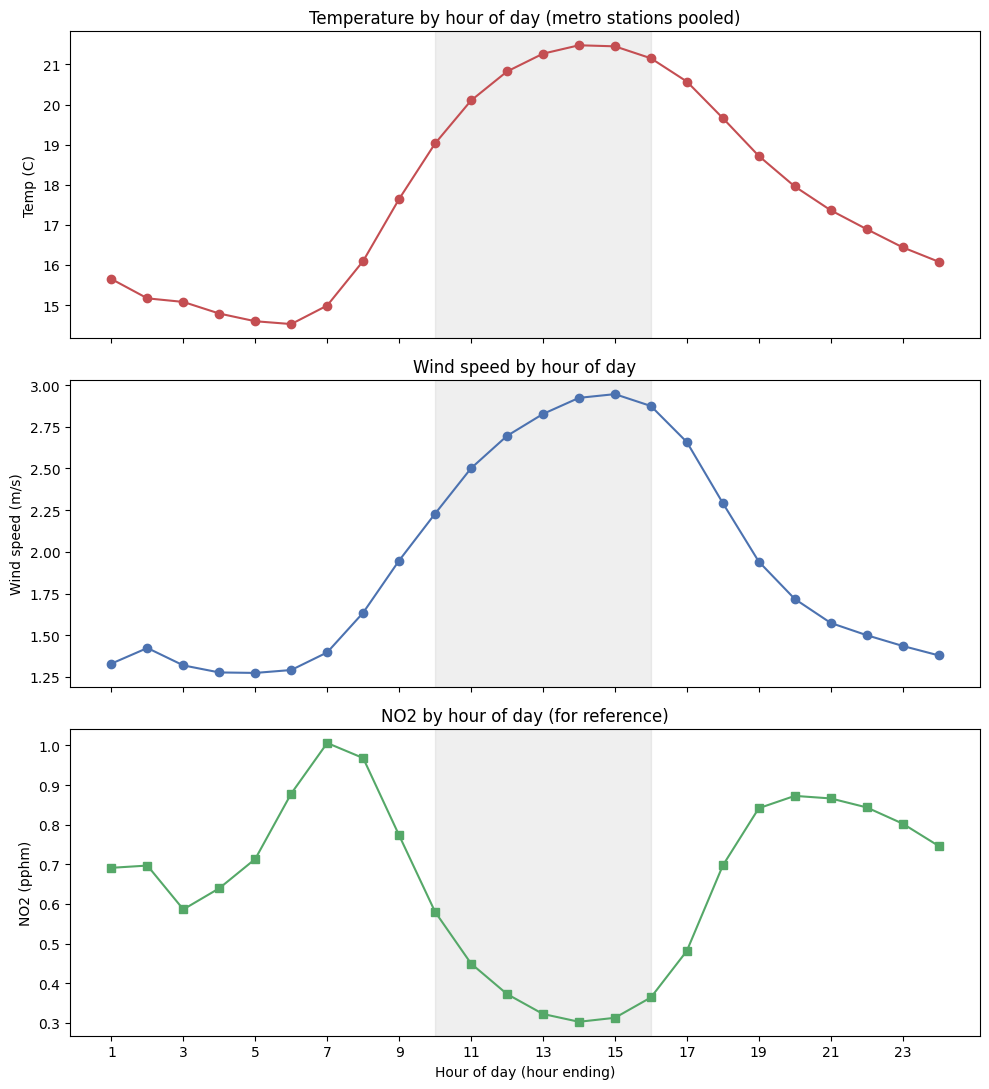

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

hourly = pd.read_csv('../data/processed/preprocessed_hourly.csv',
                      parse_dates=['date'], dtype={'station_id': str}, low_memory=False)

profile = hourly.groupby('hour_ending')[['temp_c','wind_speed_ms','no2_pphm']].mean()

fig, axes = plt.subplots(3, 1, figsize=(10,11), sharex=True)

axes[0].plot(profile.index, profile['temp_c'], marker='o', color='#C44E52')
axes[0].set_ylabel('Temp (C)'); axes[0].set_title('Temperature by hour of day (metro stations pooled)')

axes[1].plot(profile.index, profile['wind_speed_ms'], marker='o', color='#4C72B0')
axes[1].set_ylabel('Wind speed (m/s)'); axes[1].set_title('Wind speed by hour of day')

axes[2].plot(profile.index, profile['no2_pphm'], marker='s', color='#55A868')
axes[2].set_ylabel('NO2 (pphm)'); axes[2].set_title('NO2 by hour of day (for reference)')
axes[2].set_xlabel('Hour of day (hour ending)'); axes[2].set_xticks(range(1,25,2))

for ax in axes:
    ax.axvspan(10, 16, color='gray', alpha=0.12)  # highlight the NO2 trough window

plt.tight_layout()
plt.show()